# Phase 3: Model Training, Selection & Evaluation Graphs
Trains multiple candidate algorithms side-by-side, saves checkpoint dependencies, and visualizes the prediction errors.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### 1. Re-establishing Processed Datasets

In [2]:
train_df = pd.read_csv("../artifacts/train.csv")
test_df = pd.read_csv("../artifacts/test.csv")

for df in [train_df, test_df]:
    df['Pavement_Age'] = 2026 - df['Beläggningsår']

features = ['Spårdjup max 15', 'ÅDT fordon', 'Pavement_Age', 'Hastighetsgräns']
X_train = train_df[features]
y_train = train_df['IRI höger']
X_test = test_df[features]
y_actual = test_df['IRI höger']

### 2. Candidate Algorithm Execution Loop

Random_Forest_Baseline         | R²:  47.4% | MAE: 0.684 | RMSE: 1.093
HistGradientBoosting           | R²:  47.9% | MAE: 0.700 | RMSE: 1.087
GradientBoostingRegressor      | R²:  47.2% | MAE: 0.708 | RMSE: 1.095


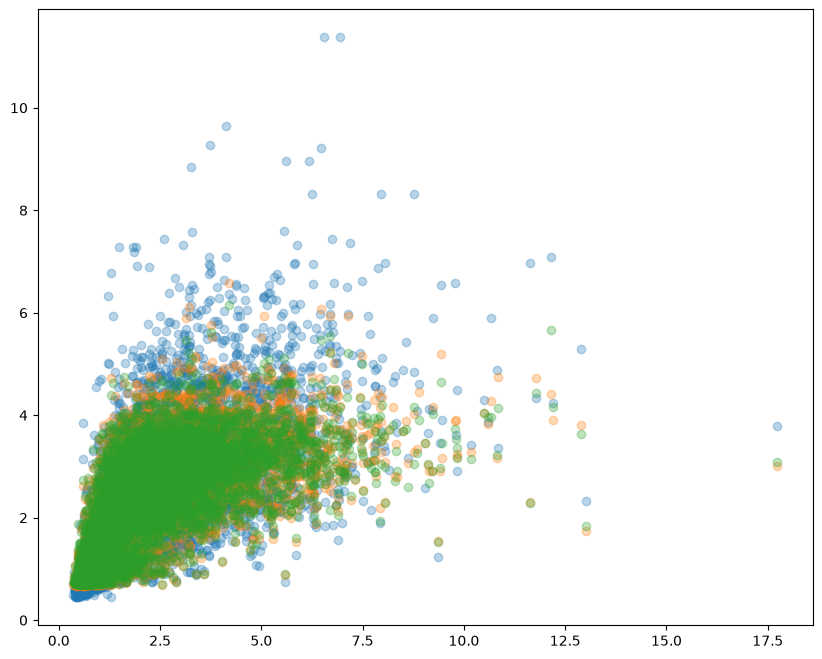

In [3]:
models = {
    "Random_Forest_Baseline": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=6, random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
}

model_report = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    
    model_report[name] = {"r2": r2, "model": model}
    print(f"{name:30} | R²: {r2*100:5.1f}% | MAE: {mae:.3f} | RMSE: {rmse:.3f}")
    
    # Append to comparison graph
    plt.scatter(y_actual, y_pred, alpha=0.3, label=f'{name} (R²: {r2*100:.1f}%)')
    
    # Save intermediate checkpoint
    with open(f"../artifacts/model_{name}.pkl", "wb") as f:
        pickle.dump(model, f)

### 3. Pick Production Winner

In [4]:
best_name = max(model_report, key=lambda k: model_report[k]["r2"])
print(f"🏆 Winning Model: {best_name}")

with open("../artifacts/model.pkl", "wb") as f:
    pickle.dump(model_report[best_name]["model"], f)

🏆 Winning Model: HistGradientBoosting


### 4. Plot Regression Fit Summary

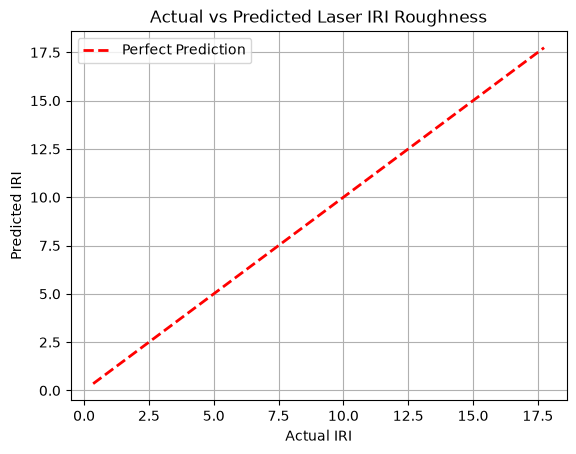

In [5]:
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Laser IRI Roughness')
plt.xlabel('Actual IRI')
plt.ylabel('Predicted IRI')
plt.legend()
plt.grid(True)
plt.savefig("../artifacts/actual_vs_predicted.png", dpi=150)
plt.show()